In [31]:
from PIL import Image#图像加载
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as transforms#图形预处理
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [32]:
#一、加载数据
#1.加载图片
image_path='Apple.jpg'
img=Image.open(image_path)

In [33]:
#2.定义并应用转化操作
transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()#转化为浮点数 并且归一化
    ])
img_tensor=transform(img)
print(img_tensor.shape)

torch.Size([3, 256, 256])


In [34]:
#3.将张量转化为numpy数组
img_ndarray=img_tensor.permute(1,2,0).numpy()
print(img_ndarray.shape)

(256, 256, 3)


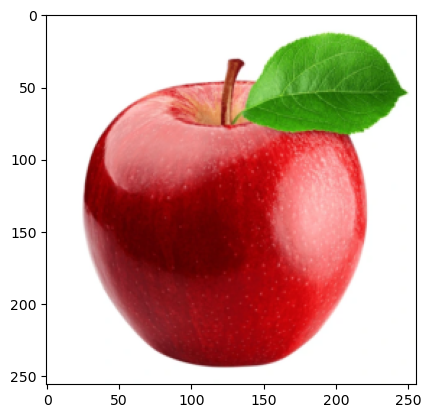

In [35]:
#4.画图
plt.imshow(img_ndarray)
plt.show()

In [36]:
#二、创建神经网络模型
import torch
import torch.nn as nn

In [37]:
#自编码器类
class AutoEncoder(nn.Module):
    def __init__(self):
        super(AutoEncoder, self).__init__()
        #编码器
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1),#形状不变
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),#砍半
            nn.Conv2d(in_channels=16, out_channels=8, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        #解码器
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=8, out_channels=16, kernel_size=3, stride=2, padding=1, output_padding=1),#2倍
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=16, out_channels=3, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()#为什么要用SIGMOD?
        )

    def forward(self,x):
        x=self.encoder(x)
        #print(x.shape)
        x=self.decoder(x)
        #print(x.shape)
        return x

In [38]:
model=AutoEncoder()
y=model(torch.randn(1,3,256,256))
print(y.shape)

torch.Size([1, 3, 256, 256])


In [39]:
#三、训练模型
import torch.optim as optim

In [40]:
#定义损失函数和超参数
loss=nn.MSELoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)
epoch_num=400

In [41]:
for epoch in range(epoch_num):
    out_put = model(img_tensor)
    loss_val = loss(out_put, img_tensor)
    loss_val.backward()
    optimizer.step()
    optimizer.zero_grad()
    if (1 + epoch) % 10 == 0:
        print(f'epoch {epoch + 1}, loss {loss_val.item():.4f}')

epoch 10, loss 0.1694
epoch 20, loss 0.1527
epoch 30, loss 0.1189
epoch 40, loss 0.1019
epoch 50, loss 0.0805
epoch 60, loss 0.0645
epoch 70, loss 0.0515
epoch 80, loss 0.0405
epoch 90, loss 0.0328
epoch 100, loss 0.0278
epoch 110, loss 0.0244
epoch 120, loss 0.0220
epoch 130, loss 0.0203
epoch 140, loss 0.0189
epoch 150, loss 0.0179
epoch 160, loss 0.0170
epoch 170, loss 0.0162
epoch 180, loss 0.0156
epoch 190, loss 0.0150
epoch 200, loss 0.0145
epoch 210, loss 0.0140
epoch 220, loss 0.0135
epoch 230, loss 0.0131
epoch 240, loss 0.0126
epoch 250, loss 0.0123
epoch 260, loss 0.0119
epoch 270, loss 0.0116
epoch 280, loss 0.0112
epoch 290, loss 0.0108
epoch 300, loss 0.0105
epoch 310, loss 0.0102
epoch 320, loss 0.0099
epoch 330, loss 0.0096
epoch 340, loss 0.0093
epoch 350, loss 0.0090
epoch 360, loss 0.0087
epoch 370, loss 0.0085
epoch 380, loss 0.0083
epoch 390, loss 0.0080
epoch 400, loss 0.0077


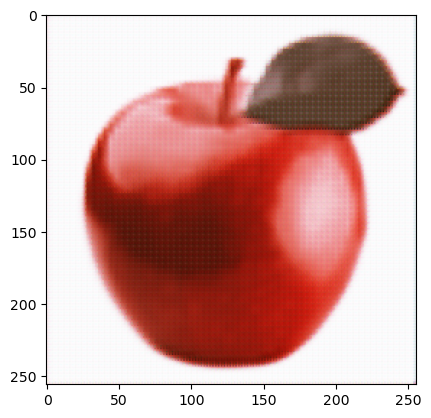

In [43]:
#四、推理(重构图形)
with torch.no_grad():
    out_put = model(img_tensor)

img_ndarray=out_put.permute(1,2,0).numpy()
plt.imshow(img_ndarray)
plt.show()